# Phase 3: Text Chunking

**Notebook:** `03_chunk_documents.ipynb`  
**Matching module:** `03_ingestion/03_chunk_documents.py`

**Purpose:** Split long hospital documents into smaller, overlapping chunks for accurate RAG retrieval while preserving source provenance and exact character offsets.

## Input and output contract

**Input:** `01_data/processed/02_cleaned_documents.json` from Phase 2.

**Data outputs:** `03_text_chunks.json`, `03_chunking_report.json`, `03_chunking_audit.csv`, and `03_rejected_chunks.json`.

**Plot outputs:** `plots/03_chunk_length_distribution.png` and `plots/03_chunks_by_source_type.png`.

In [1]:
from __future__ import annotations

import importlib.util
import json
import sys
from pathlib import Path

from IPython.display import Image, display


def find_project_root(start: Path) -> Path:
    """Locate the project from Jupyter or repository execution."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "03_ingestion" / "03_chunk_documents.py").is_file():
            return candidate
        nested = candidate / "hospital_patient_helpdesk_chatbot"
        if (nested / "03_ingestion" / "03_chunk_documents.py").is_file():
            return nested
    raise FileNotFoundError("Could not locate hospital_patient_helpdesk_chatbot.")


PROJECT_ROOT = find_project_root(Path.cwd())
PROCESSED_DATA_DIR = PROJECT_ROOT / "01_data" / "processed"
INPUT_PATH = PROCESSED_DATA_DIR / "02_cleaned_documents.json"
MODULE_PATH = PROJECT_ROOT / "03_ingestion" / "03_chunk_documents.py"

print(f"Project root: {PROJECT_ROOT}")
print(f"Input file: {INPUT_PATH}")
print(f"Chunking module: {MODULE_PATH}")


Project root: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot
Input file: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\02_cleaned_documents.json
Chunking module: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\03_ingestion\03_chunk_documents.py


In [2]:
def load_module(module_path: Path):
    """Load the numbered workflow module from its file path."""
    specification = importlib.util.spec_from_file_location("chunk_documents_module", module_path)
    if specification is None or specification.loader is None:
        raise ImportError(f"Could not load module: {module_path}")
    module = importlib.util.module_from_spec(specification)
    sys.modules[specification.name] = module
    specification.loader.exec_module(module)
    return module


chunking = load_module(MODULE_PATH)
config = chunking.ChunkingConfig(
    chunk_size=800,
    chunk_overlap=120,
    minimum_chunk_size=80,
)
config


ChunkingConfig(chunk_size=800, chunk_overlap=120, minimum_chunk_size=80)

## Why these parameters?

- **Chunk size (`800`)** keeps each retrieval unit focused while retaining enough policy context.
- **Overlap (`120`)** repeats nearby context across boundaries so facts are not isolated at a split point.
- **Minimum size (`80`)** prevents very small trailing fragments from entering the vector store.
- **Preferred boundaries** prioritize paragraphs, then sentence endings, punctuation, and whitespace before using a hard character limit.

Character-based sizing is deterministic and independent of the embedding provider. Token limits can be added later when a specific embedding model is selected.

In [3]:
documents = chunking.load_cleaned_documents(INPUT_PATH)
document_lengths = sorted(len(document["text"]) for document in documents)

print(f"Input documents: {len(documents)}")
print(f"Minimum document length: {document_lengths[0]}")
print(f"Median document length: {chunking.percentile(document_lengths, 0.50):.0f}")
print(f"Maximum document length: {document_lengths[-1]}")
print(f"Documents longer than chunk size: {sum(length > config.chunk_size for length in document_lengths)}")


Input documents: 98
Minimum document length: 120
Median document length: 165
Maximum document length: 1054
Documents longer than chunk size: 4


In [4]:
longest_document = max(documents, key=lambda document: len(document["text"]))
preview_chunks, preview_rejections = chunking.chunk_document(longest_document, config)

print(f"Source: {longest_document['source_file']}")
print(f"Original characters: {len(longest_document['text'])}")
print(f"Preview chunks: {len(preview_chunks)}")
print(f"Preview rejections: {len(preview_rejections)}")
for item in preview_chunks:
    print(
        f"\n{item.chunk_id}: offsets {item.character_start}:{item.character_end}, "
        f"{item.character_count} characters"
    )
    print(item.text[:260])


Source: manuals/patient_portal_manual.pdf
Original characters: 1054
Preview chunks: 2
Preview rejections: 0

manuals-patient-portal-manual-pdf-0001-chunk-001: offsets 0:765, 765 characters
Patient Portal User Manual

Synthetic demonstration policy for Northstar Community Hospital. Version 2026-06-14.

Account activation

Use the one-time activation link sent after registration. The link expires after 72 hours. Portal Support can issue a replacem

manuals-patient-portal-manual-pdf-0001-chunk-002: offsets 654:1054, 400 characters
targets are two business days. Many finalized results are displayed, but release timing varies. Troubleshooting

Use Forgot password first. If the registered contact information is unavailable, call Portal Support at 555-0140. Do not email identification docum


In [5]:
result = chunking.run_chunking(
    input_path=INPUT_PATH,
    output_dir=PROCESSED_DATA_DIR,
    config=config,
)
chunking.print_result(result)


Document chunking completed successfully.
Input documents: 98
Chunks created: 102
Rejected chunks: 0

Output files:
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\03_text_chunks.json (120,627 bytes)
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\03_chunking_report.json (989 bytes)
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\03_chunking_audit.csv (8,567 bytes)
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\03_rejected_chunks.json (2 bytes)
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\plots\03_chunk_length_distribution.png (33,255 bytes)
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\plot

In [6]:
chunks = json.loads(result.chunks_path.read_text(encoding="utf-8"))
report = json.loads(result.report_path.read_text(encoding="utf-8"))
rejected_chunks = json.loads(result.rejected_path.read_text(encoding="utf-8"))

if len(chunks) != report["chunks_created"]:
    raise RuntimeError("Chunk count does not match the report.")
if len({item["chunk_id"] for item in chunks}) != len(chunks):
    raise RuntimeError("Duplicate chunk IDs found.")
if any(item["character_count"] > config.chunk_size for item in chunks):
    raise RuntimeError("A chunk exceeds the configured size.")
if {item["document_id"] for item in chunks} != {item["document_id"] for item in documents}:
    raise RuntimeError("One or more source documents are missing from the chunks.")

print("Chunking validation passed.")
print(json.dumps(report, indent=2))
print(f"Rejected chunks: {len(rejected_chunks)}")


Chunking validation passed.
{
  "generated_at_utc": "2026-06-14T09:15:07.263993+00:00",
  "input_file": "C:\\Users\\Prompt\\Documents\\Hospital Patient Helpdesk Chatbot\\hospital_patient_helpdesk_chatbot\\01_data\\processed\\02_cleaned_documents.json",
  "input_documents": 98,
  "chunks_created": 102,
  "rejected_chunks": 0,
  "documents_split_into_multiple_chunks": 4,
  "configuration": {
    "chunk_size": 800,
    "chunk_overlap": 120,
    "minimum_chunk_size": 80
  },
  "chunk_length_statistics": {
    "minimum": 120,
    "maximum": 787,
    "mean": 222.25,
    "median": 174.0,
    "p95": 401.9
  },
  "chunks_by_source_type": {
    "csv": 36,
    "html": 4,
    "json": 20,
    "jsonl": 8,
    "pdf": 8,
    "sql": 1,
    "sqlite": 25
  },
  "output_files": [
    "03_text_chunks.json",
    "03_chunking_report.json",
    "03_chunking_audit.csv",
    "03_rejected_chunks.json",
    "plots/03_chunk_length_distribution.png",
    "plots/03_chunks_by_source_type.png"
  ]
}
Rejected chunks: 0

## Diagnostic plots

The first plot checks whether chunk sizes remain under the configured limit and whether many fragments are unusually small. The second plot confirms how each source format contributes to the retrieval corpus.

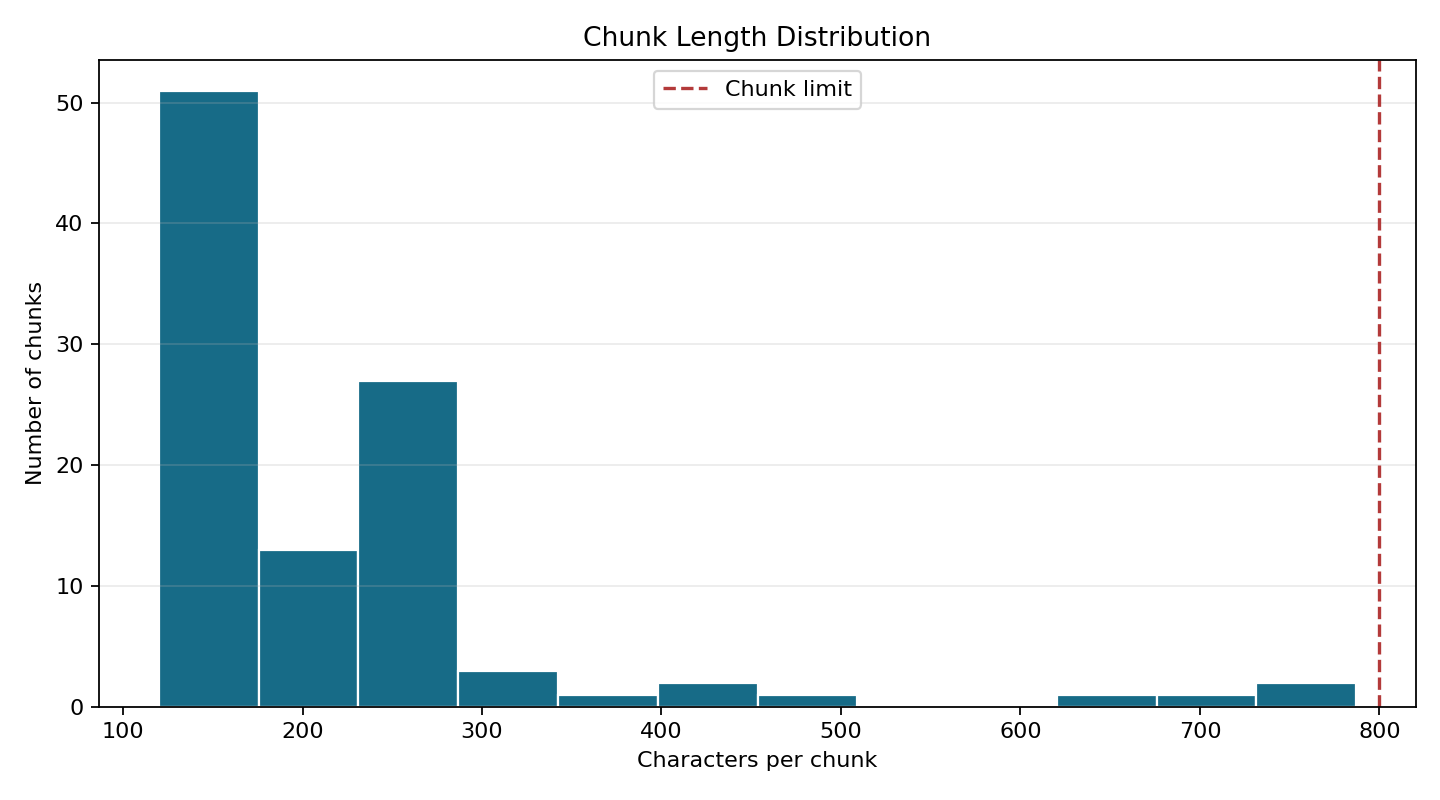

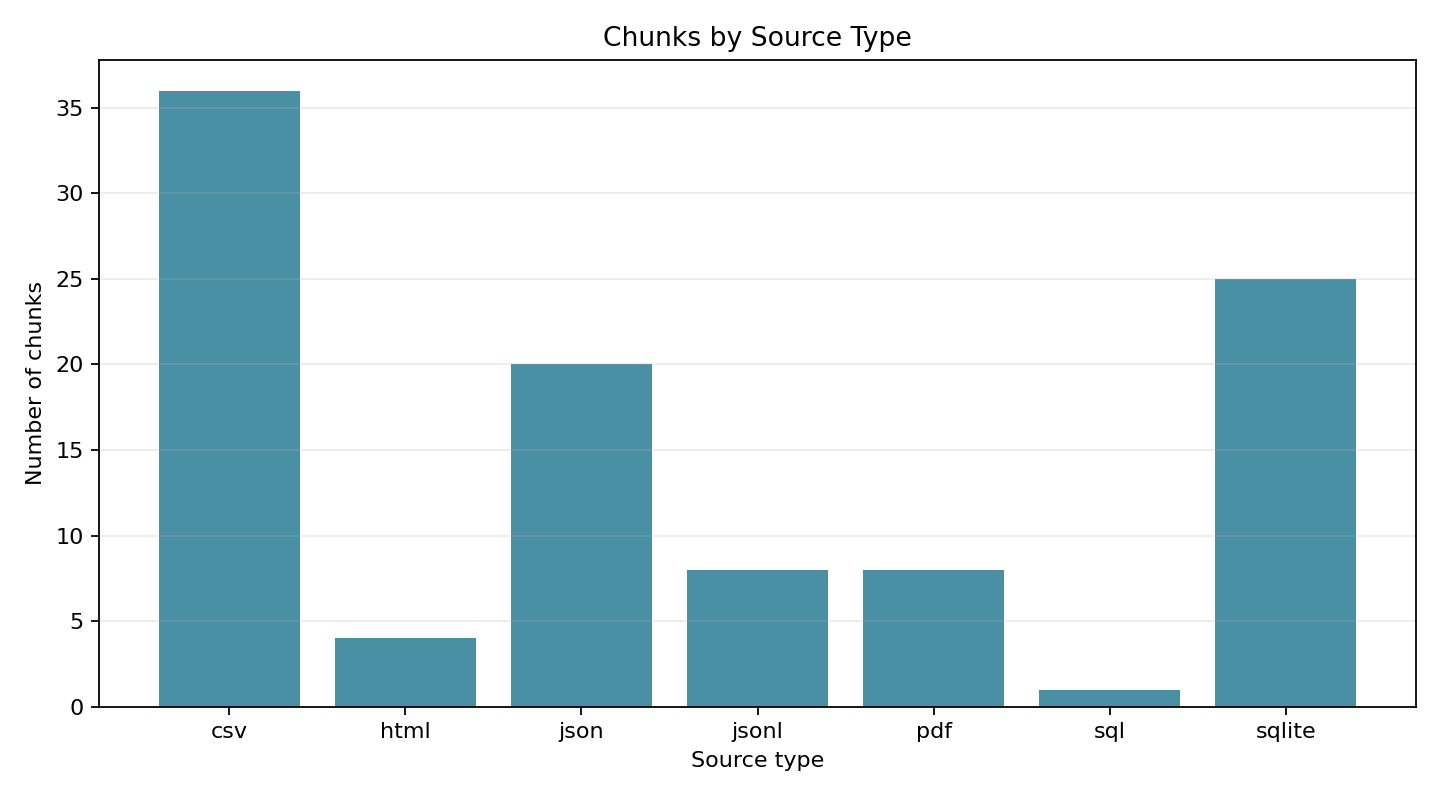

In [7]:
display(Image(filename=str(result.length_plot_path)))
display(Image(filename=str(result.source_plot_path)))


In [8]:
print("Output files:")
for output_name in report["output_files"]:
    output_path = PROCESSED_DATA_DIR / output_name
    print(f"- {output_path}: {output_path.stat().st_size:,} bytes")


Output files:
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\03_text_chunks.json: 120,627 bytes
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\03_chunking_report.json: 989 bytes
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\03_chunking_audit.csv: 8,567 bytes
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\03_rejected_chunks.json: 2 bytes
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\plots\03_chunk_length_distribution.png: 33,255 bytes
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\plots\03_chunks_by_source_type.png: 29,160 bytes


## Notebook and Python module roles

The notebook imports the Python module and adds exploration, parameter explanation, previews, report inspection, and inline plot display. The Python module contains the reusable business logic, validation, file writing, plotting functions, and command-line interface used by automation and deployment.

## Safety and next step

- Chunking never creates new medical claims; it only divides approved text.
- Source paths, IDs, offsets, cleaning details, and structured metadata remain attached to every chunk.
- Emergency and medication-safety wording may appear in overlapping chunks by design.
- Continue with `04_create_metadata.ipynb` using `03_text_chunks.json`.